In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
# Data Cleaning

In [10]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df.dropna(subset=['date_added', 'duration'], inplace=True)

In [11]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [ ]:
# Exploratory Data Analysis (EDA) 1: Movies vs Tv Shows

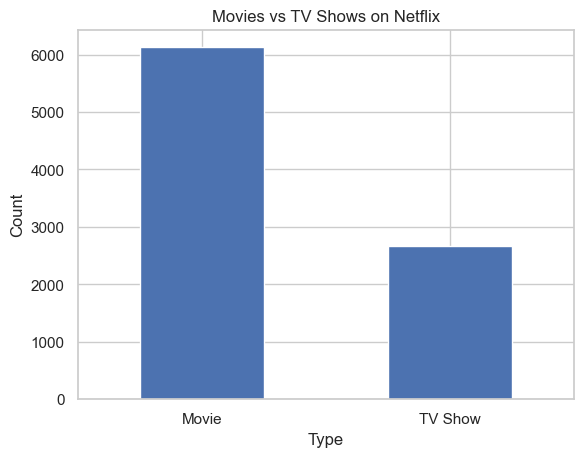

In [12]:
# Count of Movies vs TV Shows
type_counts = df['type'].value_counts()

# Plot
type_counts.plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Insight:
Majority of content on Netflix consists of Movies compared to TV Shows.

In [ ]:
#EDA 2: top 10 genres 

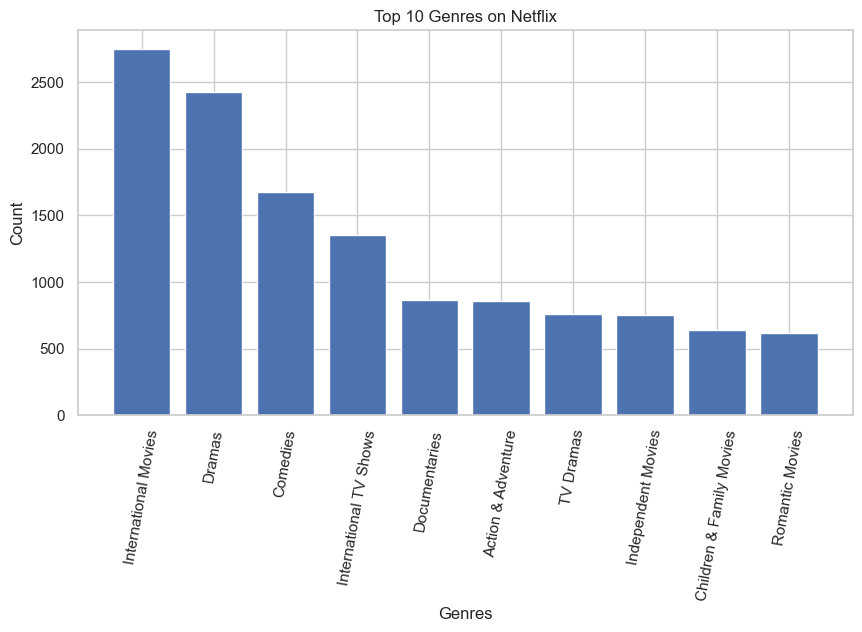

In [16]:
# Split genres
genres = df['listed_in'].str.split(', ')

# Flatten the list
all_genres = []
for sublist in genres:
    all_genres.extend(sublist)

# Count frequency
from collections import Counter
genre_counts = Counter(all_genres)

# Get top 10 genres
top_genres = dict(genre_counts.most_common(10))

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top_genres.keys(), top_genres.values())

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=80)

plt.show()

In [ ]:
# Insight:
International Movies, Dramas and Comedies are the most dominant genres on Netflix. 
This indicates that Netflix focuses heavily on globally diverse content and popular entertainment categories to attract a wide audience.

In [ ]:
# EDA:3- year wise content trend

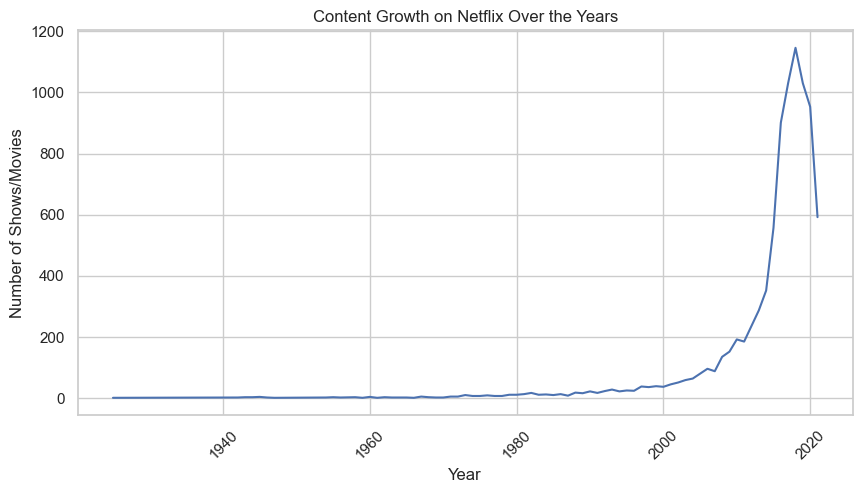

In [19]:
# Count number of shows released each year
year_counts = df['release_year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values)


plt.title("Content Growth on Netflix Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows/Movies")

plt.show()

In [ ]:
### Insight:
Netflix content has grown significantly over the years, especially after 2015, indicating rapid expansion of the platform and increased content production.

In [18]:
year_counts.tail(15)

release_year
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     287
2014     352
2015     557
2016     901
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

Top 10 Countries (Raw):
country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


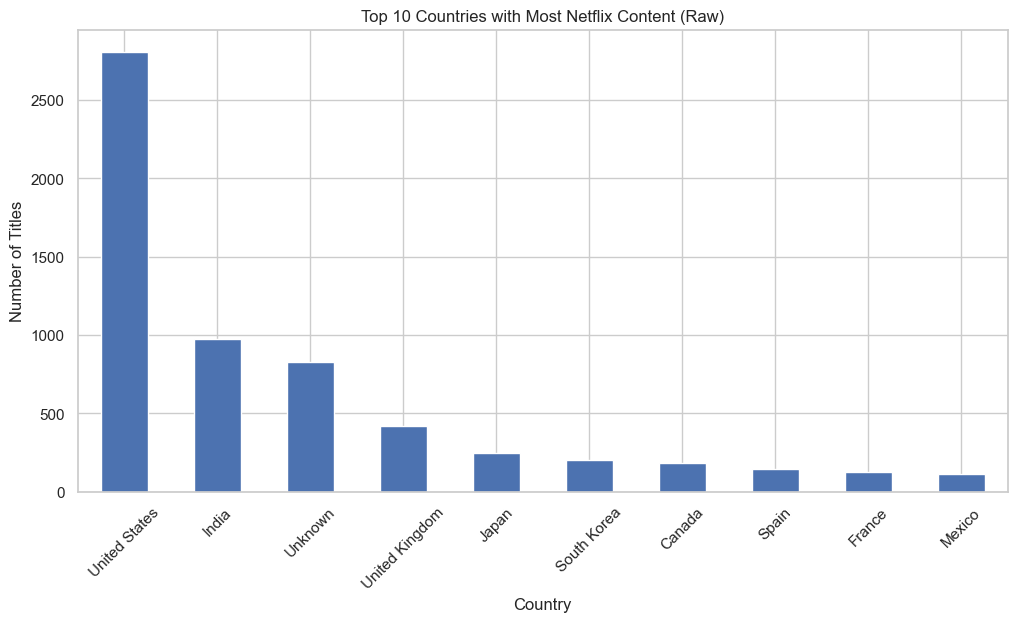


Top 10 Countries (After Splitting Multi-Country Data):
          Country  Count
0   United States   3681
1           India   1046
2         Unknown    830
3  United Kingdom    805
4          Canada    445
5          France    393
6           Japan    317
7           Spain    232
8     South Korea    231
9         Germany    226


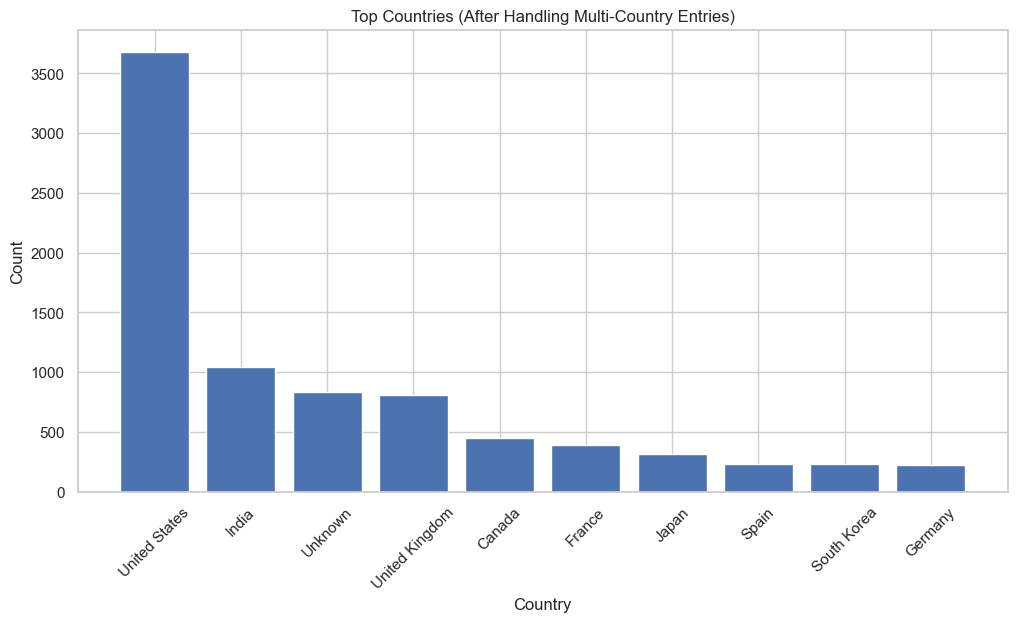

In [20]:
#EDA 4: Country-wise Analysis
# Clean Country Column
df_country = df.dropna(subset=['country']).copy()
df_country['country'] = df_country['country'].str.strip()
# Top 10 Countries (Raw Data)
top_countries = df_country['country'].value_counts().head(10)
print("Top 10 Countries (Raw):")
print(top_countries)

# Visualization (Raw Top Countries)
plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries with Most Netflix Content (Raw)")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

# Handle Multi-Country Entries

from collections import Counter

country_list = []

for countries in df_country['country']:
    for c in str(countries).split(','):
        country_list.append(c.strip())

country_counts = Counter(country_list)

top_multi_country = pd.DataFrame(
    country_counts.most_common(10),
    columns=['Country', 'Count']
)

print("\nTop 10 Countries (After Splitting Multi-Country Data):")
print(top_multi_country)

# Visualization 

plt.figure(figsize=(12,6))
plt.bar(top_multi_country['Country'], top_multi_country['Count'])

plt.title("Top Countries (After Handling Multi-Country Entries)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# EDA 4 (Improved): Country-wise Analysis After Data Cleaning

In [21]:
df_clean = df.copy()

In [22]:
df_clean = df_clean[df_clean['country'].notna()]
df_clean = df_clean[df_clean['country'] != "Unknown"]

In [23]:
df_clean['country'] = df_clean['country'].str.strip()

In [24]:
from collections import Counter

country_list = []

for countries in df_clean['country']:
    for c in str(countries).split(','):
        country_list.append(c.strip())

country_counts = Counter(country_list)

top_countries_clean = pd.DataFrame(
    country_counts.most_common(10),
    columns=['Country', 'Count']
)

top_countries_clean

,Country,Count
0,United States,3681
1,India,1046
2,United Kingdom,805
3,Canada,445
4,France,393
5,Japan,317
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


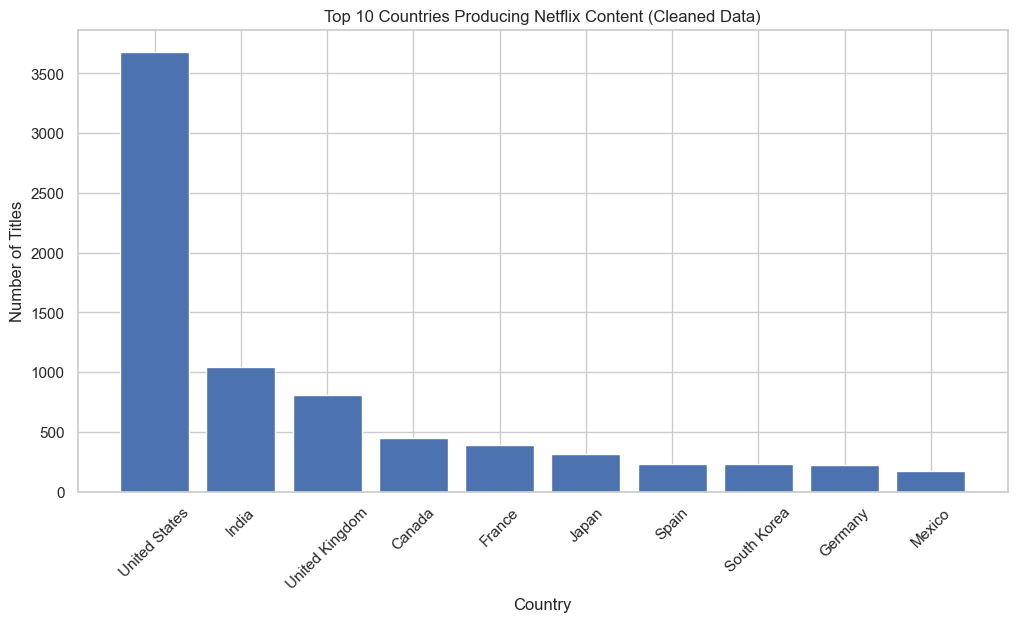

In [25]:

plt.figure(figsize=(12,6))
plt.bar(top_countries_clean['Country'], top_countries_clean['Count'])

plt.title("Top 10 Countries Producing Netflix Content (Cleaned Data)")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Insights (Country-wise Analysis)
- United States is the largest contributor of Netflix content.
- India is the second highest contributor, showing strong regional content growth.
- United Kingdom, Canada, and France also contribute significantly.
- Netflix has a highly global content distribution rather than being limited to one region.

In [ ]:
#EDA 5: Content Rating Analysis

In [26]:
df_rating = df[df['rating'].notna()].copy()
df_rating['rating'] = df_rating['rating'].str.strip()

In [27]:
rating_counts = df_rating['rating'].value_counts()
print(rating_counts)

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
NR             79
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
Name: count, dtype: int64


In [ ]:
#Rating Distribution Chart

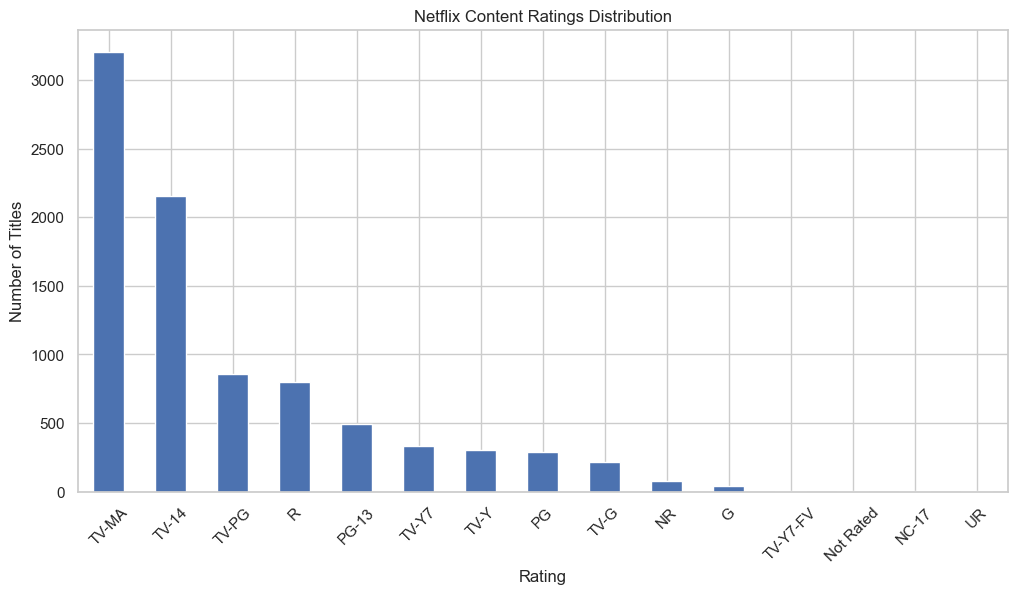

In [28]:

plt.figure(figsize=(12,6))
rating_counts.plot(kind='bar')

plt.title("Netflix Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Insights (Netflix Ratings Analysis)
- TV-MA is the most common rating, indicating Netflix focuses heavily on mature and adult content.
- TV-14 is the second highest, showing strong targeting of teenage and young adult audiences.
- TV-PG and TV-Y ratings are significantly lower, meaning less emphasis on children's content.
- Movie ratings like R and PG-13 are also highly present, reinforcing the adult-oriented content trend.
- Very few NC-17 and UR ratings suggest limited extreme adult-only or undefined content.

In [29]:
#EDA 6: Duration Analysis (Movies vs TV Shows)

In [30]:
df_duration = df.copy()

movies = df_duration[df_duration['type'] == 'Movie']
tv_shows = df_duration[df_duration['type'] == 'TV Show']

In [31]:
movies = movies.copy()

# remove "min" and convert to number
movies['duration'] = movies['duration'].str.replace(' min', '').astype(int)

In [32]:
print("Average movie duration:", movies['duration'].mean())
print("Shortest movie:", movies['duration'].min())
print("Longest movie:", movies['duration'].max())

Average movie duration: 99.57718668407311
Shortest movie: 3
Longest movie: 312


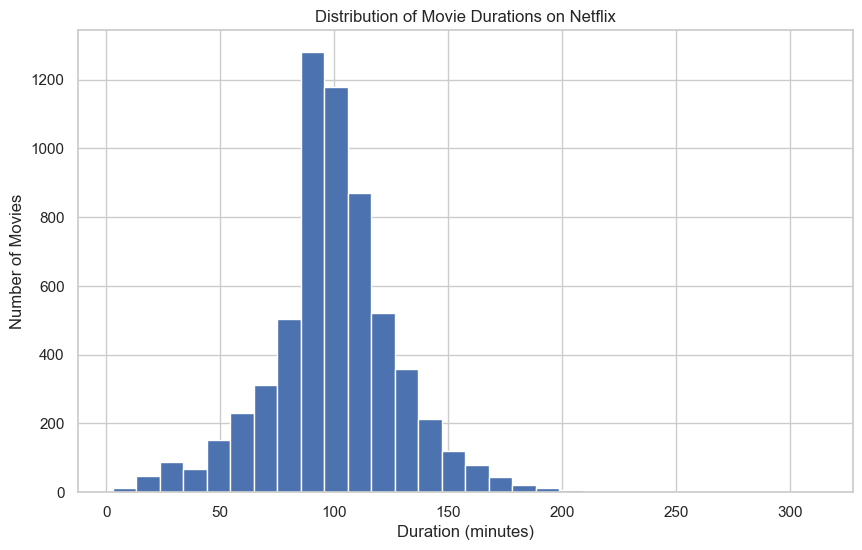

In [33]:
plt.figure(figsize=(10,6))
plt.hist(movies['duration'], bins=30)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [34]:
#TV Show Seasons Analysis

In [35]:
tv_shows = tv_shows.copy()

tv_shows['duration'] = tv_shows['duration'].str.replace(' Seasons', '')
tv_shows['duration'] = tv_shows['duration'].str.replace(' Season', '')
tv_shows['duration'] = tv_shows['duration'].astype(int)

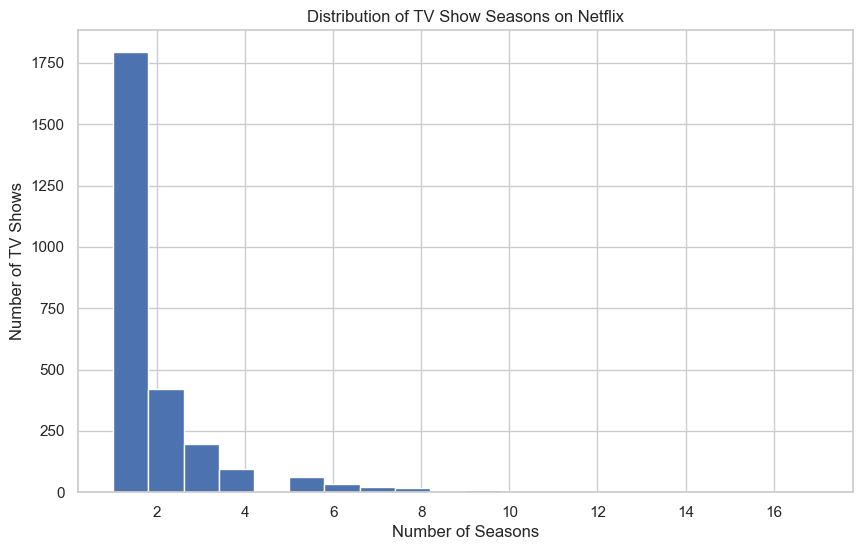

In [36]:
plt.figure(figsize=(10,6))
plt.hist(tv_shows['duration'], bins=20)

plt.title("Distribution of TV Show Seasons on Netflix")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

In [ ]:
# Insights (Duration Analysis)
- The average Netflix movie duration is around 100 minutes, showing standard film length distribution.
- Most movies fall between 80–120 minutes, indicating Netflix follows industry norms.
- Very few movies are extremely short (below 50 minutes) or very long (above 200 minutes).
- TV shows mostly have 1–2 seasons, showing that Netflix produces many limited-series content.
- A small number of TV shows have multiple seasons, indicating long-running successful series.